# **Урок 2**. Обучаем нейросети как можем

В курсе База DL вы уже очень много попрактиковались в обучении собственных сетей для задачи классификации, в том числе попробовали потюнить ```ResNet```. Это круто :)

Давайте в этом ноутбуке вспомним самые важные моменты, касающиеся построения обучения сети, работы со своими датасетами, а также того, где брать и как работать с эффективными сетками, которые мы обсудили в лекции.

## **План**


1. Заводим ```Dataset``` и знакомимся с данными.
2. Вспоминаем, как файнтюнить сеть.
3. Обучаем модель полностью (wow!).
4. Узнаем, где можно брать предобученные архитектуры.

В этом ноутбуке мы будем решать задачу многоклассовой классификации, а именно, — будем классифицировать фотографии дорожных знаков. 

Погнали!

## **1. Копаемся в данных**

Архив с датасетом можно скачать по [cсылке](https://disk.yandex.ru/d/RVaIyjVsxLDjYAс). Далее, если вы планируете работать в ```google colab```, то закиньте этот архив на свой гугл диск.  

In [ ]:
# Если вы работаете в colab, раскомментируйте эти строчки!

# прикручиваем свой гуглдиск, куда закинули архив с данными
# from google.colab import drive
# drive.mount("/content/gdrive/My Drive/", force_remount=True)

In [ ]:
# Если вы работаете в colab, раскомментируйте эти строчки и впишите свои пути

# указываем путь к данным на диске, например, у меня такой 
# разархивируем архив с данными, флаг -q - не выводить логи
# !unzip -q '/content/gdrive/My Drive/karpov.courses/lesson_2/signs.zip' -d './'

# После разархивации в директории с нашим ноутбуком появится папка signs, она-то нам и нужна

In [1]:
# импортируем всё необходимое
import os
import cv2
import PIL
import glob
import tqdm
import wandb
import random

import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F

import torchvision
import torchvision.models as models
import torchvision.transforms.v2 as transforms # обратите внимание, что тут v2 версия

from dataclasses import dataclass
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from torch.utils.data import Dataset, DataLoader

In [2]:
# посмотрим, что там у нас
print(sorted(os.listdir('./signs/TRAIN/')))
print(sorted(os.listdir('./signs/TEST/')))

['.DS_Store', '0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '6', '7', '8', '9']
['.DS_Store', '0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '5', '6', '7', '8', '9']


Структура датасета тут такова: 
- у нас нет отдельно какого-то ```DataFrame``` c именами всех картинок и их соответственных классов (хотя в большинстве случаев так и бывает)
- все картинки раскиданы по папкам, в соответствии с классом, к которому они относятся

In [3]:
# мы знаем, что все картинки у нас имеют вложенность глубины 2 в папках TRAIN/TEST, используем это и найдем все имена с помощью маски и метода glob.glob
# как работает glob можно тут почитать https://pythonworld.ru/moduli/modul-glob.html

all_train_files = sorted(glob.glob('./signs/TRAIN/*/*'))
all_test_files = sorted(glob.glob('./signs/TEST/*/*'))

In [4]:
print(all_train_files[:10], len(all_train_files))
print(all_test_files[:10], len(all_test_files))

['./signs/TRAIN/0/000_0001.png', './signs/TRAIN/0/000_0002.png', './signs/TRAIN/0/000_0003.png', './signs/TRAIN/0/000_0004.png', './signs/TRAIN/0/000_0005.png', './signs/TRAIN/0/000_0006.png', './signs/TRAIN/0/000_0007.png', './signs/TRAIN/0/000_0008.png', './signs/TRAIN/0/000_0008_j.png', './signs/TRAIN/0/000_0009.png'] 1792
['./signs/TEST/0/000_0001_j.png', './signs/TEST/0/000_0002_j.png', './signs/TEST/0/000_0003_j.png', './signs/TEST/0/000_0004_j.png', './signs/TEST/0/000_0005_j.png', './signs/TEST/0/000_0006_j.png', './signs/TEST/0/000_0007_j.png', './signs/TEST/1/001_0001_j.png', './signs/TEST/1/001_0002_j.png', './signs/TEST/1/001_0003_j.png'] 1055


Для того, чтобы поанализировать датасет, было бы довольно удобно создать ```DataFrame``` для ```train/test``` частей (но это не обязательно, и в таком виде мы могли бы придумать, как итерироваться по нему с помощью ```data.Dataset```.

Мы помним, что обычно данные включают в себя три сплита:
- на ```train``` данных обучают модель;
- на ```val``` данных подбирают гиперпараметры;
- на ```test``` данных финально оценивают качество модели (после подбора гиперпараметров).

Обычно если ```val``` часть явно не представлена, её отщипывают от ```train```, но у нас тут данных довольно мало, так что мы так шиковать не будем, а оставим только ```train``` и ```test```.

In [5]:
# используем list comprehension для того, чтобы создать списки классов для train и test
train_classes = [int(x.split('/')[-2]) for x in all_train_files]
test_classes = [int(x.split('/')[-2]) for x in all_test_files]

In [9]:
# создаем датафреймы
train_df = pd.DataFrame(zip(all_train_files, train_classes), columns=['imname', 'class'])
test_df = pd.DataFrame(zip(all_test_files, test_classes), columns=['imname', 'class'])

In [10]:
# получили типичные датафреймы с разметкой
train_df

,imname,class
0,./signs/TRAIN/0/000_0001.png,0
1,./signs/TRAIN/0/000_0002.png,0
2,./signs/TRAIN/0/000_0003.png,0
3,./signs/TRAIN/0/000_0004.png,0
4,./signs/TRAIN/0/000_0005.png,0
...,...,...
1787,./signs/TRAIN/9/010_0031.png,9
1788,./signs/TRAIN/9/010_0031_j.png,9
1789,./signs/TRAIN/9/010_0032.png,9
1790,./signs/TRAIN/9/010_0033.png,9


Посмотрим, сколько у нас представителей каждого класса в train/test частях. 

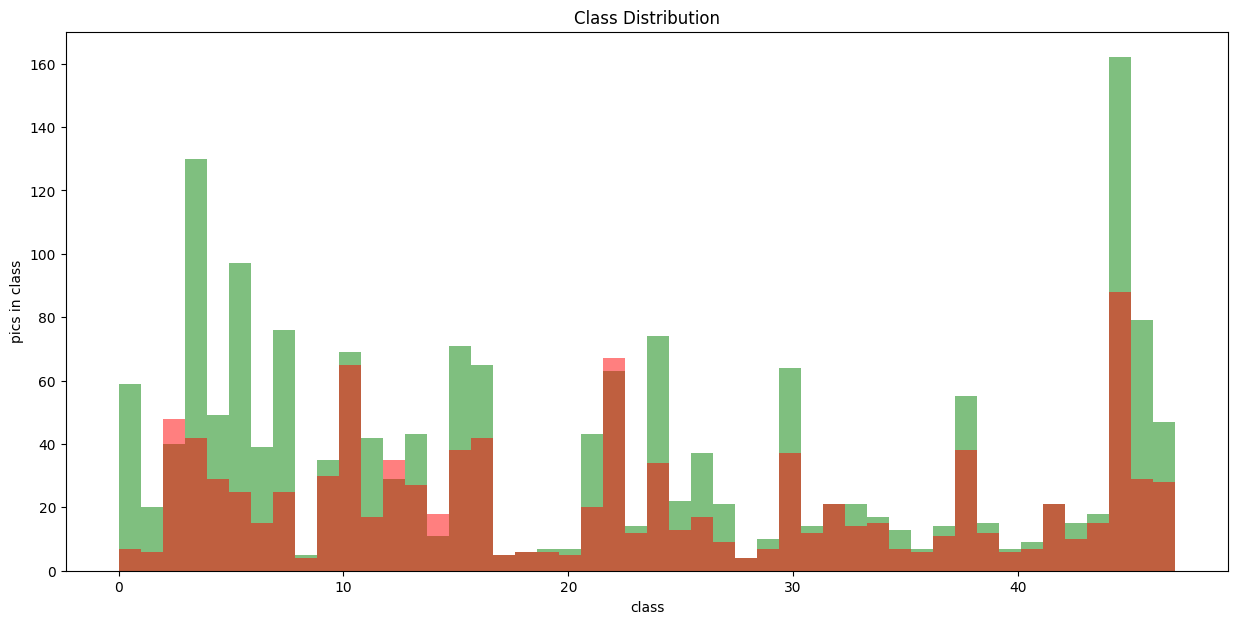

In [11]:
counts_train, bins_train = np.histogram(train_df['class'].values, bins=48)
counts_test, bins_test = np.histogram(test_df['class'].values, bins=48)
plt.figure(figsize=(15, 7))
plt.xlabel('class')
plt.ylabel('pics in class')
plt.title('Class Distribution')
plt.hist(bins_train[:-1], bins_train, weights=counts_train, color='green', alpha = 0.5)
plt.hist(bins_test[:-1], bins_test, weights=counts_test, color='red', alpha = 0.5)
plt.show()

Что мы тут видим? Довольно много классов имеют совсем мало примеров и в ```train```, и в ```test```. 

Наверное, этим классам будет сложно выучиваться, а ```accuracy``` может быть недостаточно для того, чтобы адекватно оценить качество модели. 

Окей, будем держать это в уме, из данных подготовим ```Dataset```. Всё про ```DataSets``` и ```DataLoaders``` можно почитать в официальной доке https://pytorch.org/tutorials/beginner/basics/data_tutorial.html. 

In [12]:
class SignDataset(data.Dataset): # наследуемся от data.Dataset
    """Это наш датасет

    Какие у него аргументы:
        dataframe: раз уж сделали датафрейм, будем его тут юзать
        transform: преобразование, которое будем применять к картинкам
    """
    def __init__(self, dataframe, transform=None):
        self.imlist = dataframe 
        self.transform = transform

    # это самый главный метод, он по случайному индексу должен нам возвращать одну подготовленную картинку
    def __getitem__(self, index):
        # берем строку из пришедшего df по index
        impath, target = self.imlist.loc[index]

        # если нет такой картинки, ругаемся
        if not os.path.exists(impath): 
            print('No file ', impath)
            pass

        # Сразу используем PIL для чтения, тк torchvision.transforms работает с PIL Image (https://pytorch.org/docs/stable/torchvision/transforms.html)
        img = PIL.Image.open(impath).convert('RGB')

        #применяем к изображению выбранное преобразование (аугментацию)
        img = self.transform(img)

        # на выход отдаём img, target - нужны для обучения и валидации - и impath - понадобятся нам потом для каких-нибудь визуализаций
        return img, target, impath


    # метод возвращает длину датасета - просто как длину подаваемого dataframe
    def __len__(self):
        return len(self.imlist)
    

In [13]:
# преобразование для train и test пока одинаковое, это необходимый минимум
# для преобразований будем использовать torchvision.transforms.v2, там есть почти всё мыслимое, что мы можем захотеть

transform = transforms.Compose([
    transforms.Resize((64, 64), antialias=True), # все картинки надо привести к одному
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3])
])


# создаем датасеты
trainset = SignDataset(dataframe=train_df, transform=transform)
testset = SignDataset(dataframe=test_df, transform=transform)


# по датасетам создаем даталоадеры
trainloader = DataLoader(
    trainset, 
    batch_size=32, 
    num_workers=12, 
    shuffle=True, 
    pin_memory=True,
    drop_last=True,
)

testloader = DataLoader(
    testset, 
    batch_size=32, 
    num_workers=12, 
    pin_memory=True
)

In [14]:
# тут у нас функция для разнормализации картинки и её отрисовки
def myshow(img):
    img = img * 0.3 + 0.3 # умножаем на std, прибавляем mean - в Normalize всё наоборот
    npimg = img.detach().numpy()
    fig = plt.figure(figsize=(10, 10))
    plt.imshow(npimg.transpose(1, 2, 0))

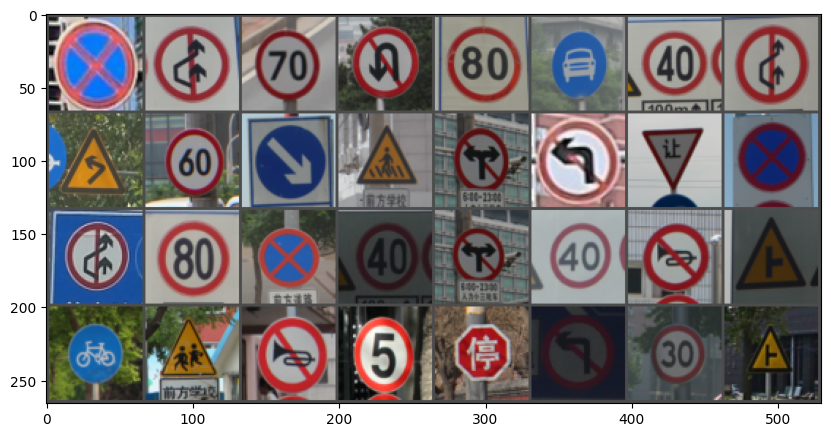

In [15]:
# заведем итератор по нашему датасету и возьмем из него случайный батч
trainiter = iter(trainloader)
images, labels, impaths = next(trainiter)

# отрисуем случайный батч
myshow(torchvision.utils.make_grid(images))

In [16]:
# проверяем, что у нас в батче всё ожидаемо
print(images.shape)
print(labels)

torch.Size([32, 3, 64, 64])
tensor([45, 13,  6, 14,  7, 24,  3, 13, 34,  5, 22, 30, 11, 10, 47, 45, 13,  7,
        45,  3, 11,  3, 16, 38, 26, 32, 16,  0, 44, 10,  2, 38])


Итак, с данными мы познакомились - это небольшие картинки с дорожными номерами. 

Для данных мы завели ```DataSet``` и ```DataLoader```, а значит, можем делать батчи из подготовленных картинок. 

Ну какие мы молодцы, можно и ```train loop``` теперь сделать. 

## **2. Вспоминаем, как файнтюнить модель**

Создаем конфиг, фиксируем всё, что можем, для воспроизводимости. 

In [17]:
def enable_determinism():
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(False) # использование тут True слишком замедляет процесс, мы так делать не будем

    
def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)
    
    
# https://pytorch.org/docs/stable/notes/randomness.html#dataloader
def seed_worker(_):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [18]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24

    # Данные
    batch_size: int = 32
    img_size: int = 64

    # Обучение
    n_epochs: int = 10
    lr: float = 1e-4


config = Config()
enable_determinism()
fix_seeds(config.seed)


# создаем генератор и устанавливаем для него seed
# чтобы гарантировать воспроизводимость как тут: https://pytorch.org/docs/stable/notes/randomness.html#dataloader
generator = torch.Generator()
generator.manual_seed(config.seed)

In [19]:
# Создадим ещё раз, но учитывая воспроизводимость
transform = transforms.Compose([
    transforms.Resize((config.img_size, config.img_size), antialias=True), # все картинки надо привести к одному размеру и не забыть про асиасинг
    transforms.PILToTensor(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize([0.3, 0.3, 0.3], [0.3, 0.3, 0.3])
])


trainset = SignDataset(dataframe=train_df, transform=transform)
testset = SignDataset(dataframe=test_df, transform=transform)

trainloader = DataLoader(
    trainset, 
    batch_size=32, 
    num_workers=12, 
    shuffle=True, 
    pin_memory=True,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=generator,
)

testloader = DataLoader(
    testset, 
    batch_size=32, 
    num_workers=12, 
    pin_memory=True
)

In [20]:
trainiter = iter(trainloader)
images, labels, impaths = next(trainiter)
print(labels)

tensor([12, 45,  4, 26, 15, 10, 16, 42,  5, 22,  3, 22, 33, 15,  3, 45,  2, 32,
        41, 38, 45, 26, 30, 46, 13, 45,  3, 33, 11, 16, 45, 45])


In [21]:
# Установим девайс в зависимости от того, что нам доступно
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    # Apple Silicon
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Device: ', device)

Device:  cuda


In [22]:
# Проверим, какие у нас версии библиотек, у меня на данный момент они новейшие
print(torch.__version__)
print(torchvision.__version__)

2.4.0+cu124
0.19.0+cu124


In [23]:
# заведем единую функцию и для обучения, и для эвала
# по сути эти процессы отличаются только режимом работы сети
def run_epoch(epoch, net, loader, criterion, optimizer, device, is_train):
    """
    Training and evaluaton loop over samples
    
    Args:
        train_mode (bool): True for train mode
    """
    if is_train:
        net.train()
    else:
        net.eval()
        
    running_loss = 0.0
    correct = 0.0
    total = 0.0
    all_preds = []
    all_labels = []

    for i, data in enumerate(loader):
        # берем батч, кладем на девайс
        images, labels, _= data
        images, labels = images.to(device), labels.to(device)

        # мы всегда прогоняем батч через сеть и считаем loss
        outputs = net(images)
        loss = criterion(outputs, labels)

        # занулять градиенты, считать новые, обновлять веса - всё нужно только на обучении
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # пополняем логи
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds = np.concatenate((all_preds, predicted.cpu().numpy()))
        all_labels = np.concatenate((all_labels, labels.cpu().numpy()))
    
    acc = (all_preds == all_labels).sum()/len(all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    # после обучения/валидации логируем
    print('Loss: {:.3f}, accuracy: {:.3f}, balanced: {:.3f}'.format(running_loss / (i + 1), acc * 100.0, bal_acc * 100.0))
    if is_train:
        wandb.log({'train loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'train accuracy': acc * 100.0}, step=epoch)
        wandb.log({'train balanced accuracy': bal_acc * 100.0}, step=epoch)
    else:
        wandb.log({'test loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'test accuracy': acc * 100.0}, step=epoch)
        wandb.log({'test balanced accuracy': bal_acc * 100.0}, step=epoch)
        
    return all_preds, all_labels

In [24]:
## разбираемся с моделькой

# берем предобученную на ImageNet модель
# если не указать weights, то получим модель со случайной инициализацией
# https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
net = models.resnet50(weights='DEFAULT')


# последний слой меняем на 48 нейронов
# https://pytorch.org/docs/stable/generated/torch.nn.Linear.html
net.fc = nn.Linear(net.fc.in_features, 48)

# переносим модельку на девайс
net = net.to(device)

# для обучения возьмем только параметры последнего слоя
train_params = [v for k, v in net.named_parameters() if k in {'fc.weight', 'fc.bias'}]

In [25]:
# давайте посмотрим на структуру сети
net

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

При печати архитектуры видно, из каких слоев она должна состоять, но никаких ```skip connenctions``` или ещё какие-нибудь особенностей прохода по сети тут не отследить. 

Чтобы точно знать, что происходит с картинкой по мере прохождения через сеть, надо смотреть ```source code``` архитектуры, а точнее, что происходит в ```forward()```: https://pytorch.org/vision/main/_modules/torchvision/models/resnet.html

In [26]:
# гиперпараметры завели

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(train_params, lr=config.lr)

In [27]:
# инициализируем эксперимент в wandb
wandb.init(
    project="lesson-2", 
    name="finetune_resnet_50", 
    config=config.__dict__
)

fix_seeds(config.seed)

# и погнали итерироваться
for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: belnasty24 (belnasty24-karpov-courses). Use `wandb login --relogin` to force relogin


Training epoch:  1 / 10
Loss: 3.635, accuracy: 11.775, balanced: 6.006
Validation
Loss: 3.609, accuracy: 11.185, balanced: 7.484
----------------------
Training epoch:  2 / 10
Loss: 3.233, accuracy: 28.069, balanced: 14.191
Validation
Loss: 3.419, accuracy: 18.957, balanced: 11.216
----------------------
Training epoch:  3 / 10
Loss: 2.925, accuracy: 40.011, balanced: 20.994
Validation
Loss: 3.250, accuracy: 25.024, balanced: 15.842
----------------------
Training epoch:  4 / 10
Loss: 2.701, accuracy: 51.897, balanced: 28.921
Validation
Loss: 3.143, accuracy: 28.910, balanced: 18.620
----------------------
Training epoch:  5 / 10
Loss: 2.479, accuracy: 56.194, balanced: 31.936
Validation
Loss: 3.033, accuracy: 31.564, balanced: 20.635
----------------------
Training epoch:  6 / 10
Loss: 2.300, accuracy: 62.835, balanced: 38.142
Validation
Loss: 2.925, accuracy: 34.502, balanced: 22.154
----------------------
Training epoch:  7 / 10
Loss: 2.167, accuracy: 65.737, balanced: 40.608
Valida

test accuracy,▁▃▄▅▆▇▇▇██
test balanced accuracy,▁▂▄▅▆▆▆▇▇█
test loss,█▇▅▅▄▃▂▂▁▁
train accuracy,▁▃▄▆▆▇▇███
train balanced accuracy,▁▂▃▅▅▆▇▇██
train loss,█▆▅▄▄▃▂▂▁▁
test accuracy,39.24171
test balanced accuracy,27.61913
test loss,2.6402
train accuracy,73.71652
train balanced accuracy,49.98487


## **3. Обучаем модель полностью**

In [28]:
net = models.resnet50(weights='DEFAULT')
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)

In [29]:
optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)

In [30]:
# инициализируем эксперимент в wandb
wandb.init(
    project="lesson-2", 
    name="train_full_resnet_50", 
    config=config.__dict__
)

# и погнали итерироваться
for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 10
Loss: 2.818, accuracy: 43.359, balanced: 26.529
Validation
Loss: 2.382, accuracy: 46.540, balanced: 28.326
----------------------
Training epoch:  2 / 10
Loss: 0.822, accuracy: 83.092, balanced: 58.177
Validation
Loss: 1.334, accuracy: 65.877, balanced: 49.079
----------------------
Training epoch:  3 / 10
Loss: 0.262, accuracy: 94.922, balanced: 82.272
Validation
Loss: 1.017, accuracy: 72.512, balanced: 63.849
----------------------
Training epoch:  4 / 10
Loss: 0.097, accuracy: 97.935, balanced: 93.082
Validation
Loss: 0.876, accuracy: 75.261, balanced: 68.646
----------------------
Training epoch:  5 / 10
Loss: 0.036, accuracy: 99.609, balanced: 98.529
Validation
Loss: 0.799, accuracy: 77.156, balanced: 70.316
----------------------
Training epoch:  6 / 10
Loss: 0.021, accuracy: 99.665, balanced: 99.313
Validation
Loss: 0.761, accuracy: 79.336, balanced: 73.284
----------------------
Training epoch:  7 / 10
Loss: 0.018, accuracy: 99.833, balanced: 99.684
Vali

test accuracy,▁▅▆▇▇█▇███
test balanced accuracy,▁▄▆▇▇█████
test loss,█▄▂▂▁▁▁▁▁▁
train accuracy,▁▆▇███████
train balanced accuracy,▁▄▆▇██████
train loss,█▃▂▁▁▁▁▁▁▁
test accuracy,79.24171
test balanced accuracy,74.36855
test loss,0.69672
train accuracy,99.9442
train balanced accuracy,99.81061


А что было бы, если бы мы учили нашу модель с нуля?

In [31]:
# Делаем всё то же, но без весов
net = models.resnet50()
net.fc = nn.Linear(net.fc.in_features, 48)
net = net.to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)

In [32]:
wandb.init(
    project="lesson-2", 
    name="train_full_resnet_50_from_scratch", 
    config=config.__dict__
)

# и погнали итерироваться
for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        _, _ = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')
wandb.finish()

Training epoch:  1 / 10
Loss: 3.464, accuracy: 13.616, balanced: 4.907
Validation
Loss: 3.982, accuracy: 8.720, balanced: 3.977
----------------------
Training epoch:  2 / 10
Loss: 3.129, accuracy: 19.922, balanced: 8.289
Validation
Loss: 4.177, accuracy: 10.616, balanced: 5.556
----------------------
Training epoch:  3 / 10
Loss: 2.813, accuracy: 28.627, balanced: 13.338
Validation
Loss: 3.826, accuracy: 16.682, balanced: 9.192
----------------------
Training epoch:  4 / 10
Loss: 2.390, accuracy: 38.114, balanced: 19.409
Validation
Loss: 3.333, accuracy: 23.602, balanced: 13.752
----------------------
Training epoch:  5 / 10
Loss: 1.936, accuracy: 48.828, balanced: 27.481
Validation
Loss: 3.402, accuracy: 23.223, balanced: 12.623
----------------------
Training epoch:  6 / 10
Loss: 1.524, accuracy: 58.203, balanced: 35.322
Validation
Loss: 3.250, accuracy: 26.635, balanced: 18.638
----------------------
Training epoch:  7 / 10
Loss: 1.226, accuracy: 66.741, balanced: 44.891
Validation

test accuracy,▁▂▃▅▅▆▇▇▇█
test balanced accuracy,▁▁▃▄▄▆▆▆▇█
test loss,▇█▆▃▄▃▂▃▁▁
train accuracy,▁▂▂▃▄▅▆▇██
train balanced accuracy,▁▁▂▃▄▄▅▆▇█
train loss,█▇▆▅▄▃▃▂▁▁
test accuracy,34.21801
test balanced accuracy,26.55243
test loss,2.96346
train accuracy,84.375
train balanced accuracy,67.1288


Итак, 
- обучать модель целиком - это несравнимо **более эффективно**, чем пытаться настраивать только веса последнего ```fc``` слоя
- при этом обучать модель целиком **с нуля** - затея так себе (по крайней мере на нашем масштабе данных)

Всегда используйте инициализацию и учите модель целиком.

## **4. Нужно больше моделей**

Очень сомневаюсь, что вы будете сами писать с нуля модели под каждую задачку. Да и на ```ResNet``` всё-таки свет клином не сошелся.

Почти всегда вы будете брать готовые архитектуры из ```open-source``` источников. Откуда же их брать?

Основных источников три:
- ```torchvision.models```: https://pytorch.org/vision/stable/models.html
- ```PyTorch Image Models - timm```: https://github.com/huggingface/pytorch-image-models
- ```Hugging Face```: https://huggingface.co/models

Давайте попробуем проделать всё то же самое с ```EfficientNet_b1``` из ```torchvision.models```.

In [33]:
# остальное так же
net = models.efficientnet_b1(weights='DEFAULT')

In [34]:
# посмотрим, как выглядит модель, чтобы понять, как последний слой поменять
net

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [35]:
net.classifier[1] = nn.Linear(net.classifier[1].in_features, 48)
net = net.to(device)

# проверим, что всё ок
print(net.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=48, bias=True)
)


In [36]:
optimizer = torch.optim.Adam(net.parameters(), lr=config.lr)

In [37]:
wandb.init(
    project="lesson-2", 
    name="train_full_effnet_b1", 
    config=config.__dict__
)

# и погнали итерироваться
for epoch in range(config.n_epochs):
    # training
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    _, _ = run_epoch(epoch, net, trainloader, criterion, optimizer, device, is_train=True)

    # validation
    print('Validation')
    with torch.no_grad():
        preds, labels = run_epoch(epoch, net, testloader, criterion, optimizer, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')
wandb.finish()

Training epoch:  1 / 10
Loss: 3.690, accuracy: 16.741, balanced: 8.987
Validation
Loss: 3.573, accuracy: 25.118, balanced: 13.580
----------------------
Training epoch:  2 / 10
Loss: 2.967, accuracy: 48.661, balanced: 26.780
Validation
Loss: 2.944, accuracy: 37.346, balanced: 23.093
----------------------
Training epoch:  3 / 10
Loss: 1.937, accuracy: 62.277, balanced: 37.108
Validation
Loss: 2.189, accuracy: 47.678, balanced: 31.020
----------------------
Training epoch:  4 / 10
Loss: 1.207, accuracy: 74.275, balanced: 49.872
Validation
Loss: 1.804, accuracy: 51.943, balanced: 37.171
----------------------
Training epoch:  5 / 10
Loss: 0.836, accuracy: 80.971, balanced: 57.798
Validation
Loss: 1.544, accuracy: 55.071, balanced: 42.252
----------------------
Training epoch:  6 / 10
Loss: 0.623, accuracy: 86.105, balanced: 67.708
Validation
Loss: 1.429, accuracy: 58.863, balanced: 47.567
----------------------
Training epoch:  7 / 10
Loss: 0.504, accuracy: 88.002, balanced: 71.466
Valid

test accuracy,▁▃▅▆▆▇▇███
test balanced accuracy,▁▂▄▄▅▆▇▇██
test loss,█▆▄▃▂▂▂▁▁▁
train accuracy,▁▄▅▆▇▇▇███
train balanced accuracy,▁▃▄▅▅▆▇▇██
train loss,█▇▄▃▂▂▂▁▁▁
test accuracy,66.63507
test balanced accuracy,61.03838
test loss,1.12117
train accuracy,94.92188
train balanced accuracy,87.66752


Итак, наши модельки идеально (на 95-100%) выучили все картинки на ```train```-е, но справляются при этом только с 70-80% картинок на тесте.

Давайте посмотрим как будет выглядеть ```confusion matrix``` последнего эксперимента. 

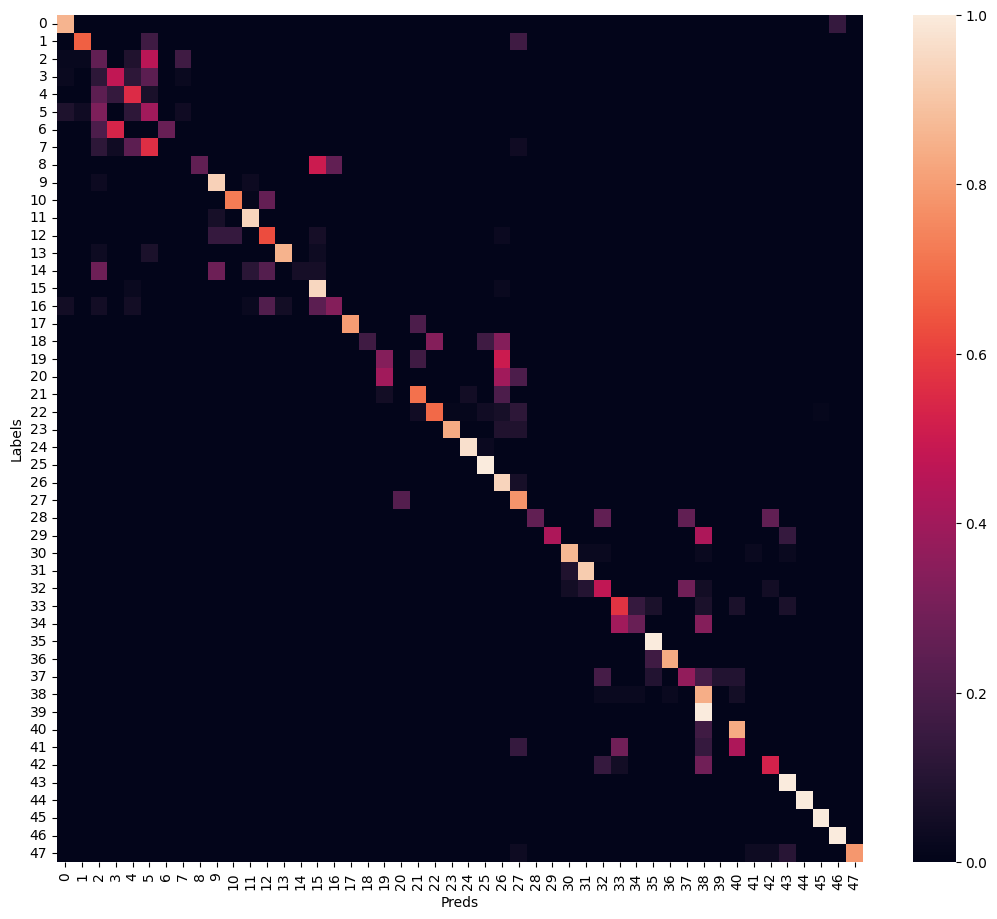

In [38]:
cm = confusion_matrix(labels, preds, normalize='true')
                                
plt.figure(figsize = (13, 11))
ax = sn.heatmap(cm)
ax.set(xlabel='Preds', ylabel='Labels')
plt.show()

Способы улучшения этого результата мы разберем в следующем уроке. 

## **Итоги**

Итак, сегодня мы
1. Попробовали решить задачу многоклассовой классификации
2. Вспомнили, как строить ```train loop``` и ```DataSet```
3. Вспомнили, как делать fine-tuning модели
4. Поняли, что вместо этого намного эффективнее дообучать всю модель
5. Узнали, откуда можно брать готовые предобученные модели

В следующий раз попробуем получить совсем классные результаты, 

See you!